# 01 · Exploração dos microdados do ENEM 2023

Primeiro contato com os dados: por que eles precisam de preparo, quem são os
inscritos, qual recorte usar e uma primeira olhada nas três dimensões do
projeto (escola, renda e estado).

In [1]:
import sys
import time
import zipfile

sys.path.append("../src")

import matplotlib.pyplot as plt
import pandas as pd

from base import carregar, concluintes
from dicionario import COLUNAS, DTYPES
from graficos import AZUL, CINZA, aplicar_estilo, salvar

aplicar_estilo()
pd.set_option("display.float_format", "{:.1f}".format)

## 1. Por que não ler o CSV direto?

O CSV tem 1,8 GB e 76 colunas. Vamos comparar, numa amostra de 300 mil
linhas, a leitura ingênua (todas as colunas, tipos automáticos) com a leitura
do `preparar.py` (só as colunas usadas e tipos enxutos).

In [2]:
ZIP = "../data/raw/microdados_enem_2023.zip"
CSV = "microdados_enem_2023/DADOS/MICRODADOS_ENEM_2023.csv"
AMOSTRA = 300_000


def ler_amostra(**opcoes):
    inicio = time.perf_counter()
    with zipfile.ZipFile(ZIP) as z, z.open(CSV) as f:
        df = pd.read_csv(f, sep=";", encoding="latin-1", nrows=AMOSTRA, **opcoes)
    return df, time.perf_counter() - inicio


ingenuo, t_ingenuo = ler_amostra()
enxuto, t_enxuto = ler_amostra(usecols=COLUNAS, dtype=DTYPES)

fator = 3_933_955 / AMOSTRA
comparacao = pd.DataFrame({
    "colunas": [ingenuo.shape[1], enxuto.shape[1]],
    "MB na amostra": [ingenuo.memory_usage(deep=True).sum() / 1e6,
                      enxuto.memory_usage(deep=True).sum() / 1e6],
    "segundos": [t_ingenuo, t_enxuto],
}, index=["ingênuo", "enxuto"])
comparacao["MB estimados (arquivo todo)"] = comparacao["MB na amostra"] * fator
comparacao

,colunas,MB na amostra,segundos,MB estimados (arquivo todo)
ingênuo,76,278.1,2.5,3646.8
enxuto,23,29.6,2.1,387.8


A maior parte da memória da leitura ingênua vai para as colunas `TX_RESPOSTAS_*`
e `TX_GABARITO_*`, que guardam as 45 respostas de cada prova como texto e não
são usadas aqui. Descartar essas colunas e usar tipos pequenos (`int8`,
`float32`, `category`) é o que permite trabalhar com os 3,9 milhões de linhas
num notebook comum.

Depois do `preparar.py`, o arquivo inteiro vira um Parquet de ~46 MB que
carrega em menos de um segundo:

In [3]:
inicio = time.perf_counter()
df = carregar()
print(f"{len(df):,} linhas carregadas em {time.perf_counter() - inicio:.1f} s, "
      f"{df.memory_usage(deep=True).sum() / 1e6:.0f} MB em memória")

3,933,955 linhas carregadas em 0.3 s, 153 MB em memória


## 2. Quem faz o ENEM?

In [4]:
df["TP_ST_CONCLUSAO"].value_counts(normalize=True).mul(100).round(1).rename("%")

TP_ST_CONCLUSAO
Já concluiu                        48.2
Conclui em 2023                    35.6
Conclui após 2023                  15.8
Não concluiu e não está cursando    0.4
Name: %, dtype: float64

Só cerca de um terço dos inscritos está no último ano do ensino médio. O
resto já concluiu (gente tentando de novo, ou voltando a estudar anos depois)
ou é **treineiro**, aluno do 1º ou 2º ano que faz a prova só para treinar.

### A armadilha do tipo de escola

A coluna `TP_ESCOLA` parece ter 64% de "Não respondeu". Mas, cruzando com a
situação de conclusão, esses não são alunos que se recusaram a responder:

In [5]:
pd.crosstab(df["TP_ST_CONCLUSAO"], df["TP_ESCOLA"])

TP_ESCOLA,Não respondeu,Pública,Privada
TP_ST_CONCLUSAO,,,
Já concluiu,1895301,0,0
Conclui em 2023,5,1166540,234619
Conclui após 2023,620067,0,0
Não concluiu e não está cursando,17423,0,0


**O INEP só registra o tipo de escola de quem conclui o ensino médio em
2023.** Para todos os outros o campo é sempre "Não respondeu". Uma média de
"Não respondeu" contra "Pública" e "Privada" estaria comparando grupos de idade
e trajetória totalmente diferentes.

## 3. O recorte da análise

Daqui em diante usamos `concluintes()` (em `src/base.py`):

- **concluem o ensino médio em 2023**: o único grupo com tipo de escola;
- **presentes nas 4 provas**: quem falta a um dia fica com nota vazia, e
  incluir essas pessoas misturaria desempenho com abstenção;
- `MEDIA` = média simples das cinco notas (4 provas objetivas + redação).

In [6]:
base = concluintes(df)
print(f"{len(base):,} concluintes presentes "
      f"({len(base) / (df['TP_ST_CONCLUSAO'] == 'Conclui em 2023').sum():.0%} dos concluintes inscritos)")
base[["NU_NOTA_CN", "NU_NOTA_CH", "NU_NOTA_LC", "NU_NOTA_MT", "NU_NOTA_REDACAO", "MEDIA"]].describe().T

1,050,863 concluintes presentes (75% dos concluintes inscritos)


,count,mean,std,min,25%,50%,75%,max
NU_NOTA_CN,1050863.0,489.5,84.7,0.0,435.2,487.3,544.2,868.4
NU_NOTA_CH,1050863.0,519.0,85.0,0.0,464.5,525.5,578.8,823.0
NU_NOTA_LC,1050863.0,514.9,73.4,0.0,469.0,520.1,566.3,820.8
NU_NOTA_MT,1050863.0,530.9,128.7,0.0,429.8,520.2,625.5,958.6
NU_NOTA_REDACAO,1050863.0,630.3,214.9,0.0,520.0,640.0,800.0,1000.0
MEDIA,1050863.0,536.9,95.7,0.0,472.3,537.0,604.0,862.6


## 4. Primeira olhada

### Tipo de escola

`TP_ESCOLA` separa só pública e privada. Para abrir a pública em federal,
estadual e municipal usamos `TP_DEPENDENCIA_ADM_ESC`, que o INEP preenche
apenas para parte dos concluintes (é o cadastro da escola, não a declaração
do aluno).

In [7]:
print(f"dependência administrativa preenchida para "
      f"{base['TP_DEPENDENCIA_ADM_ESC'].notna().mean():.0%} dos concluintes")

por_rede = (base.groupby("TP_DEPENDENCIA_ADM_ESC", observed=True)["MEDIA"]
            .agg(["mean", "median", "count"]))
por_rede

dependência administrativa preenchida para 69% dos concluintes


,mean,median,count
TP_DEPENDENCIA_ADM_ESC,,,
Federal,595.0,601.2,43946
Estadual,510.8,513.8,456911
Municipal,523.2,525.9,5832
Privada,616.7,624.3,214740


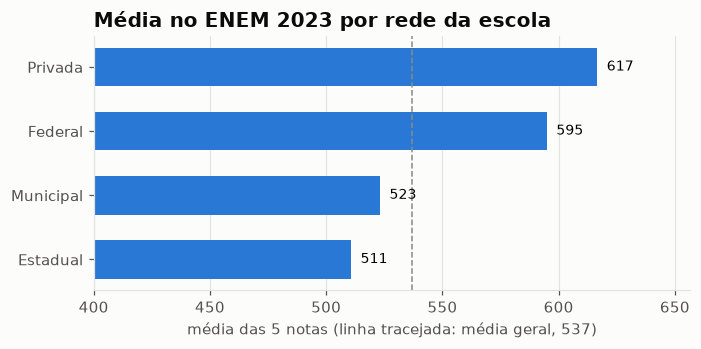

In [8]:
media_geral = base["MEDIA"].mean()
serie = por_rede["mean"].sort_values()

fig, ax = plt.subplots(figsize=(7, 3))
ax.barh(serie.index.astype(str), serie.values, color=AZUL, height=0.6)
ax.axvline(media_geral, color=CINZA, linewidth=1, linestyle="--")
for y, valor in enumerate(serie.values):
    ax.text(valor + 4, y, f"{valor:.0f}", va="center", fontsize=9)
ax.set_xlim(400, serie.max() + 40)
ax.grid(axis="y", visible=False)
ax.set_title("Média no ENEM 2023 por rede da escola")
ax.set_xlabel(f"média das 5 notas (linha tracejada: média geral, {media_geral:.0f})")
salvar(fig, "01_media_por_rede");

O eixo começa em 400 para as diferenças ficarem visíveis. As barras mostram
a distância entre as redes, não o tamanho absoluto da nota.

### Renda familiar

In [9]:
por_renda = base.groupby("Q006", observed=True)["MEDIA"].agg(["mean", "count"])
por_renda["% alunos"] = por_renda["count"] / por_renda["count"].sum() * 100
por_renda

,mean,count,% alunos
Q006,,,
Nenhuma renda,472.3,56183,5.3
Até 1.320,494.4,311101,29.6
1.320 a 1.980,521.5,159878,15.2
1.980 a 2.640,536.1,116799,11.1
2.640 a 3.300,548.4,84539,8.0
3.300 a 3.960,560.5,51735,4.9
3.960 a 5.280,572.1,80304,7.6
5.280 a 6.600,586.3,43008,4.1
6.600 a 7.920,594.5,26755,2.5


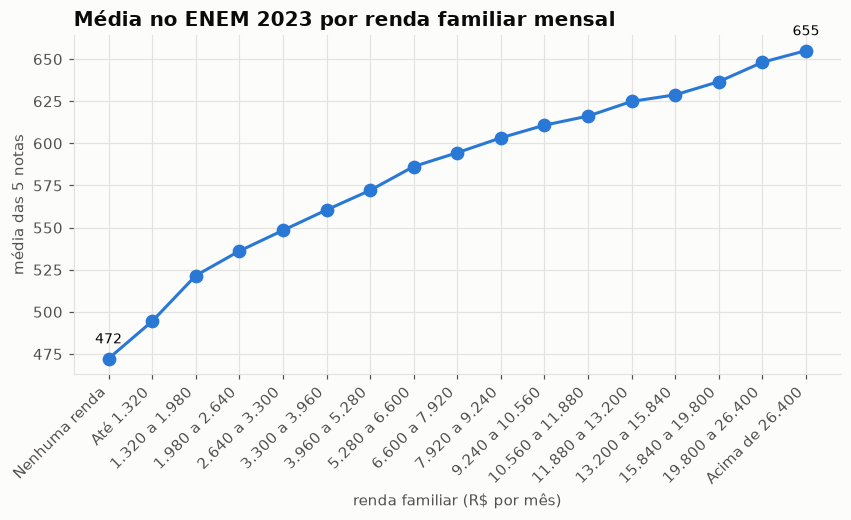

In [10]:
fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(range(len(por_renda)), por_renda["mean"], color=AZUL, marker="o")
ax.set_xticks(range(len(por_renda)), por_renda.index.astype(str), rotation=45, ha="right")
for x in [0, len(por_renda) - 1]:
    ax.annotate(f"{por_renda['mean'].iloc[x]:.0f}", (x, por_renda["mean"].iloc[x]),
                textcoords="offset points", xytext=(0, 10), ha="center", fontsize=9)
ax.set_title("Média no ENEM 2023 por renda familiar mensal")
ax.set_xlabel("renda familiar (R$ por mês)")
ax.set_ylabel("média das 5 notas")
salvar(fig, "01_media_por_renda");

### Estado (UF onde fez a prova)

SG_UF_PROVA
AM   491.4
MA   497.4
CE   505.3
SC   557.2
SP   557.3
MG   562.6
Name: média, dtype: float32

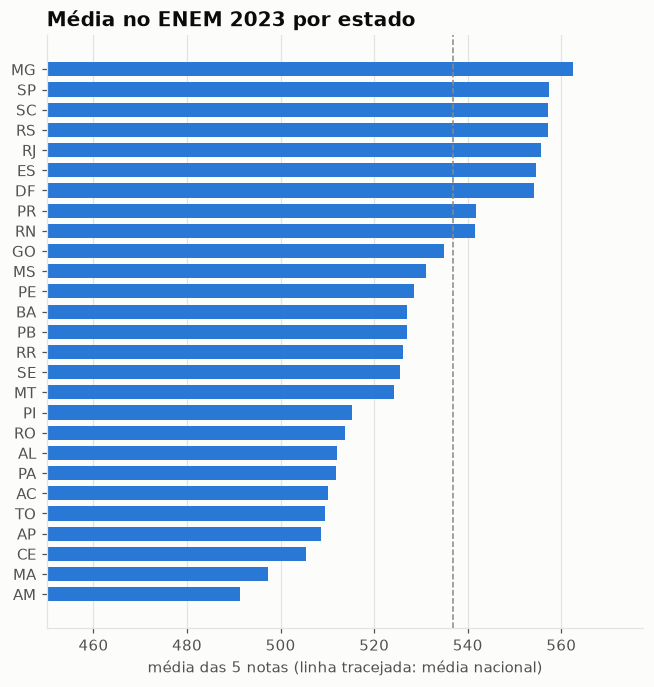

In [11]:
por_uf = base.groupby("SG_UF_PROVA", observed=True)["MEDIA"].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 7))
ax.barh(por_uf.index.astype(str), por_uf.values, color=AZUL, height=0.7)
ax.axvline(media_geral, color=CINZA, linewidth=1, linestyle="--")
ax.set_xlim(450, por_uf.max() + 15)
ax.grid(axis="y", visible=False)
ax.set_title("Média no ENEM 2023 por estado")
ax.set_xlabel("média das 5 notas (linha tracejada: média nacional)")
salvar(fig, "01_media_por_uf")
pd.concat([por_uf.head(3), por_uf.tail(3)]).rename("média")

## O que já dá para ver

- **Escola**: a rede privada (617) e a federal (595) ficam bem acima da estadual
  (511), que concentra dois terços dos concluintes com escola identificada.
  A federal (institutos federais e colégios de aplicação) chega perto da
  privada.
- **Renda**: a média sobe em todas as faixas, de 472 (sem renda) a 655 (acima
  de R$ 26,4 mil), ou seja, 183 pontos. A subida é mais rápida nas primeiras
  faixas: só de "Nenhuma renda" para "1.320 a 1.980" são 49 pontos.
- **Estado**: 71 pontos separam MG (563) e AM (491). Sul, Sudeste e DF ficam
  acima da média nacional, e Norte e Nordeste abaixo, com exceção do RN.

Essas diferenças se sobrepõem: escolas privadas concentram alunos de renda
alta, e estados mais ricos têm mais alunos de renda alta. **A próxima pergunta
é quanto de cada diferença sobra quando se compara alunos parecidos**, por
exemplo pública e privada dentro da mesma faixa de renda.

Isso é o que o `02_cruzamentos.ipynb` responde.